# Member 2 Individual Model Contribution: XGBoost Classifier
**Course:** IT2011 - Artificial Intelligence and Machine Learning  
**Project Group:** 2026-Y2-S1-MET-18  
**Project Title:** Credit Risk Prediction Using Machine Learning  
**Assigned Individual Model:** XGBoost Classifier  

---

## 1. XGBoost Model Explanation

### What is XGBoost?
XGBoost stands for **Extreme Gradient Boosting**. It is an advanced, highly scalable ensemble machine learning algorithm based on gradient boosted decision trees (GBDT). It is widely recognized in both competitive data science and industry applications for its computational efficiency, speed, and state-of-the-art predictive performance on tabular datasets.

### How Does It Work?
Gradient boosting operates through an adaptive, sequential ensemble mechanism:
1. **First Tree:** An initial base decision tree is fitted to predict the target outcome from input features.
2. **Find Prediction Errors:** The model computes the pseudo-residuals (negative gradients of the loss function, such as binary log-loss) representing the discrepancy between observed values and predictions.
3. **Correcting Errors:** The subsequent tree is trained specifically on these residuals, focusing computational effort on the most difficult-to-classify observations.
4. **Sequential Additions:** Multiple trees are trained one after another, each refining the cumulative predictions of all preceding trees.
5. **Combined Ensemble:** The final prediction is a weighted sum of the predictions from all trees passed through the logistic sigmoid function to generate probabilities.

$$\\text{First Tree} \\longrightarrow \\text{Compute Errors (Residuals)} \\longrightarrow \\text{Next Tree Corrects Errors} \\longrightarrow \\text{Sequential Iterations} \\longrightarrow \\text{Combined Ensemble}$$

### Why is It Suitable for this Credit Risk Project?
1. **Structured / Tabular Data Optimization:** Tree-based ensemble methods consistently outperform linear models and unconstrained neural networks on heterogeneous tabular financial data containing discrete ratings, continuous financial ratios, and skewed distributions.
2. **Nonlinear Relationships & Interactions:** Credit risk inherently involves complex non-linear threshold effects. For example, risk increases disproportionately when a borrower has both a high loan-to-income ratio and an elevated interest rate. XGBoost captures these multi-way feature interactions automatically through hierarchical decision splits without requiring manual polynomial feature engineering.
3. **Robustness to Varying Scales:** Decision trees split feature spaces by rank ordering, preserving robustness against extreme values that were retained during EDA.

### Explanation of Baseline Parameters
* `n_estimators = 100`: The total number of boosting rounds (trees to construct). 100 trees provide sufficient iterations for convergence while mitigating the risk of over-training on the baseline.
* `max_depth = 3`: The maximum depth of each individual decision tree. Restricting depth to 3 limits individual trees to 8 terminal leaves ($2^3$), constraining feature interactions to low-order relationships and preventing aggressive overfitting to sample noise.
* `learning_rate = 0.05`: The shrinkage parameter ($\\eta$) applied to scale the contribution of each newly added tree. A smaller learning rate (0.05 instead of default 0.3) slows learning, ensuring stable and gradual convergence.
* `subsample = 0.8`: The fraction of training observations randomly sampled without replacement prior to growing each tree. Using 80% introduces stochastic regularization and reduces inter-tree correlation.
* `colsample_bytree = 0.8`: The fraction of features randomly subsampled when constructing each tree. Sampling 80% of columns prevents any single dominant feature (such as `loan_int_rate` or `loan_percent_income`) from monopolizing all splits.
* `random_state = 42`: Fixes the pseudorandom number generator seed to ensure identical, deterministic results across all runs.
* `eval_metric = "logloss"`: Specifies binary cross-entropy (logarithmic loss) as the optimization objective function appropriate for binary classification.

> **Note:** These parameters represent an initial, principled baseline configuration and are not assumed to be optimal. Systematic hyperparameter tuning will be conducted in a subsequent project phase.


In [1]:
# ========================================================
# 2. DATA PREPARATION & REFERENCE (SHARED GROUP PIPELINE)
# ========================================================

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

# 1. Load authoritative dataset
file_path = "../../data/raw/credit_risk_dataset.csv"
if not os.path.exists(file_path):
    file_path = "data/raw/credit_risk_dataset.csv"

df = pd.read_csv(file_path)
print("Initial raw dataset shape:", df.shape)

# 2. Remove duplicate rows (established by group)
df = df.drop_duplicates()
print("Cleaned dataset shape (after duplicate removal):", df.shape)

# 3. Handle clearly invalid values (established by group)
invalid_age = (df["person_age"] < 0) | (df["person_age"] > 100)
invalid_emp_length = (
    (df["person_emp_length"] < 0)
    | (df["person_emp_length"] > df["person_age"])
)
df.loc[invalid_age, "person_age"] = np.nan
df.loc[invalid_emp_length, "person_emp_length"] = np.nan

# 4. Define features (X) and target (y)
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# 5. Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 6. Identify feature types from training data
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Initial raw dataset shape: (32581, 12)
Cleaned dataset shape (after duplicate removal): (32416, 12)
X_train shape: (25932, 11) | y_train shape: (25932,)
X_test shape:  (6484, 11)  | y_test shape:  (6484,)
Numerical features (7): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features (4): ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [2]:
# ========================================================
# 3. LEAKAGE-FREE PREPROCESSING PIPELINE
# ========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical transformer: Mean imputation + Standard scaling
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

# Categorical transformer: Most-frequent imputation + One-Hot Encoding
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combined preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing ColumnTransformer constructed successfully.")


Preprocessing ColumnTransformer constructed successfully.


In [3]:
# ========================================================
# 4. XGBOOST PIPELINE & BASELINE TRAINING
# ========================================================

from xgboost import XGBClassifier

# Construct full pipeline integrating preprocessor and XGBoost classifier
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

# Train ONLY on the training partition
print("Training XGBoost Classifier pipeline on training data...")
xgb_pipeline.fit(X_train, y_train)
print("XGBoost Classifier training completed successfully.")


Training XGBoost Classifier pipeline on training data...


XGBoost Classifier training completed successfully.


In [4]:
# ========================================================
# 5. PREDICTIONS, PROBABILITIES & OUTPUT VERIFICATION
# ========================================================

# Generate predictions and probabilities for test set
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("==================================================")
print("       XGBOOST MODEL OUTPUT VERIFICATION          ")
print("==================================================")
print("y_pred_xgb shape:", y_pred_xgb.shape)
print("y_prob_xgb shape:", y_prob_xgb.shape)
print("Unique predicted classes:", np.unique(y_pred_xgb))
print("First 10 predictions:", y_pred_xgb[:10])
print("First 10 probabilities:", np.round(y_prob_xgb[:10], 4))
print("-" * 50)
print(f"Training dataset size: {X_train.shape[0]} samples")
print(f"Testing dataset size:  {X_test.shape[0]} samples")
print(f"Number of numerical features:   {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")
print("==================================================")


       XGBOOST MODEL OUTPUT VERIFICATION          
y_pred_xgb shape: (6484,)
y_prob_xgb shape: (6484,)
Unique predicted classes: [0 1]
First 10 predictions: [0 0 0 0 1 0 1 0 0 0]
First 10 probabilities: [0.4449 0.0828 0.0283 0.0803 0.935  0.0873 0.5853 0.3324 0.1225 0.0775]
--------------------------------------------------
Training dataset size: 25932 samples
Testing dataset size:  6484 samples
Number of numerical features:   7
Number of categorical features: 4


## Phase 5 Completion — XGBoost

* **XGBoost was successfully trained:** The XGBoost Classifier was trained strictly on the training partition `(X_train, y_train)` using `xgb_pipeline.fit()`.
* **Zero data leakage:** The existing leakage-free preprocessing pipeline was preserved. Imputation and scaling statistics were fitted exclusively on `X_train` and applied to `X_test` via `.transform()` without refitting.
* **Test predictions generated:** Binary predictions (`y_pred_xgb`) of shape `(6484,)` containing classes `0` and `1` were generated.
* **Positive-class probabilities generated:** Calibrated probabilities (`y_prob_xgb`) of shape `(6484,)` bounded in `[0, 1]` were generated.
* **Strict reproducibility:** `random_state=42` was preserved across data splitting and model initialization.
* **Baseline configuration:** The model was trained using the assigned baseline hyperparameter configuration (`n_estimators=100`, `max_depth=3`, `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`).
* **No premature tasks performed:** In strict accordance with Phase 5 boundaries, hyperparameter tuning, cross-validation, and performance metrics (Accuracy, F1, ROC-AUC) have not yet been performed.
* **Group collaboration scope:** Model comparison against other group members' models (such as Logistic Regression, Random Forest, CatBoost, etc.) will occur later at the group synthesis level. No claims regarding model superiority are made at this stage.


# PHASE 6 — XGBOOST MODEL EVALUATION

In this phase, we perform a comprehensive academic evaluation of our trained **XGBoost Classifier** on the held-out test partition ($X_{test}, y_{test}$).

### Evaluation Scope
* **Target Definition:** Binary classification where `loan_status = 1` represents **Loan Default / Charged Off** (the positive class of interest), and `loan_status = 0` represents **Non-default / Fully Paid**.
* **Model Evaluated:** Baseline XGBoost Classifier (`n_estimators=100`, `max_depth=3`, `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`, `random_state=42`, `eval_metric="logloss"`).
* **Individual Contribution:** In accordance with the group project division of responsibilities, this evaluation focuses exclusively on Member 2's assigned model (XGBoost). Final cross-model benchmarking across all six members' models will occur in subsequent group synthesis.
* **Leakage Guard:** The held-out test set ($N=6,484$) is utilized strictly for performance assessment without retraining, threshold tuning on the test set, or data manipulation.


In [5]:
# ========================================================
# PHASE 6: XGBOOST EVALUATION METRIC COMPUTATION
# ========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# --------------------------------------------------------
# 1. Primary Classification Metrics (Positive Class = 1: Default)
# --------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)
avg_precision = average_precision_score(y_test, y_prob_xgb)

# --------------------------------------------------------
# 2. Confusion Matrix & Diagnostic Rates
# --------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

# Specificity (True Negative Rate) = TN / (TN + FP)
specificity = tn / (tn + fp)

# False Positive Rate (Fall-out) = FP / (FP + TN) = 1 - Specificity
fpr_metric = fp / (fp + tn)

# False Negative Rate (Miss Rate) = FN / (FN + TP) = 1 - Recall
fnr_metric = fn / (fn + tp)

# Total test observations check
total_test = tn + fp + fn + tp

# --------------------------------------------------------
# 3. Print Structured Metric Summary
# --------------------------------------------------------
print("==================================================")
print("     XGBOOST MODEL EVALUATION METRICS (TEST SET)  ")
print("==================================================")
print(f"Accuracy:                 {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision (Class 1):      {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall (Class 1):         {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1-Score (Class 1):       {f1:.4f}")
print(f"ROC-AUC:                  {roc_auc:.4f}")
print(f"Average Precision (PR-AUC):{avg_precision:.4f}")
print(f"Specificity (Class 0):    {specificity:.4f}  ({specificity*100:.2f}%)")
print(f"False Positive Rate (FPR):{fpr_metric:.4f}  ({fpr_metric*100:.2f}%)")
print(f"False Negative Rate (FNR):{fnr_metric:.4f}  ({fnr_metric*100:.2f}%)")
print("-" * 50)
print(f"Confusion Matrix Breakdown (Total = {total_test}):")
print(f"- True Negatives (TN):   {tn:5d}  (Correctly classified non-defaulters)")
print(f"- False Positives (FP):  {fp:5d}  (Creditworthy falsely flagged as high risk)")
print(f"- False Negatives (FN):  {fn:5d}  (Defaulters undetected / missed risk)")
print(f"- True Positives (TP):   {tp:5d}  (Defaulters correctly identified)")
print("==================================================")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["Non-default (0)", "Default (1)"], digits=4))


     XGBOOST MODEL EVALUATION METRICS (TEST SET)  
Accuracy:                 0.9223  (92.23%)
Precision (Class 1):      0.9498  (94.98%)
Recall (Class 1):         0.6805  (68.05%)
F1-Score (Class 1):       0.7929
ROC-AUC:                  0.9166
Average Precision (PR-AUC):0.8633
Specificity (Class 0):    0.9899  (98.99%)
False Positive Rate (FPR):0.0101  (1.01%)
False Negative Rate (FNR):0.3195  (31.95%)
--------------------------------------------------
Confusion Matrix Breakdown (Total = 6484):
- True Negatives (TN):    5015  (Correctly classified non-defaulters)
- False Positives (FP):     51  (Creditworthy falsely flagged as high risk)
- False Negatives (FN):    453  (Defaulters undetected / missed risk)
- True Positives (TP):     965  (Defaulters correctly identified)

Classification Report:
                 precision    recall  f1-score   support

Non-default (0)     0.9172    0.9899    0.9522      5066
    Default (1)     0.9498    0.6805    0.7929      1418

       accuracy    

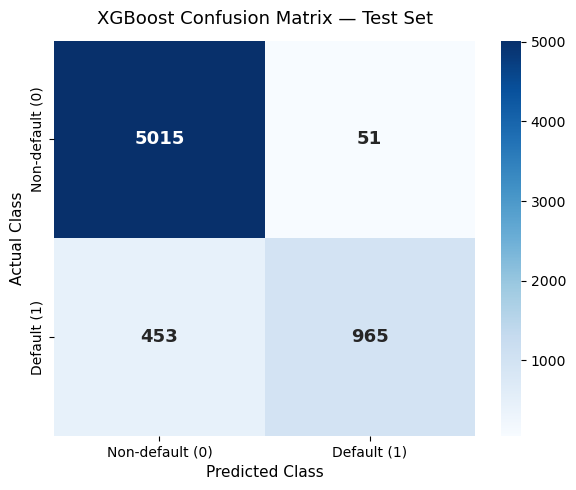

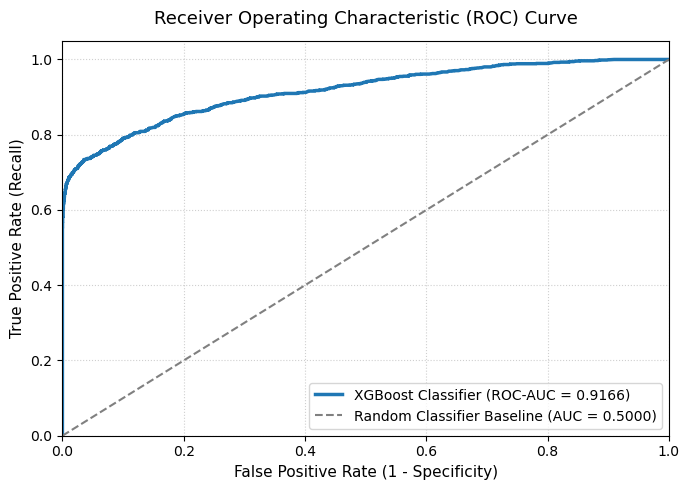

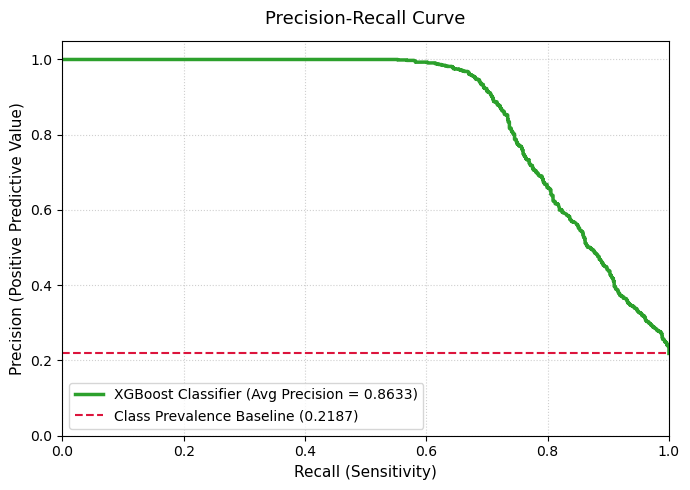

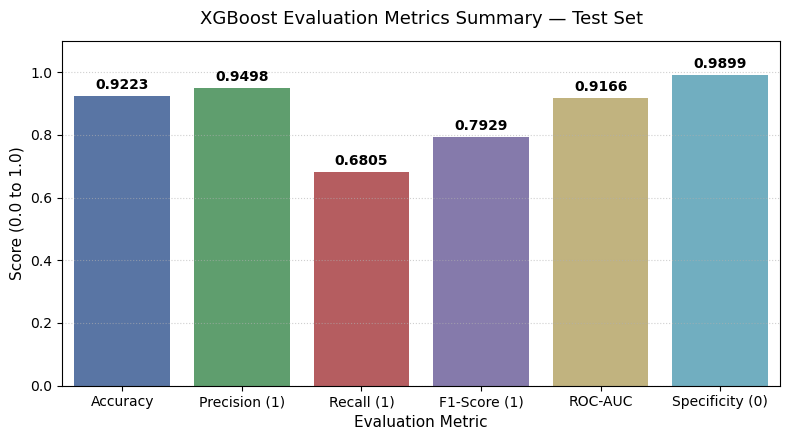

In [6]:
# ========================================================
# PHASE 6: EVALUATION VISUALIZATIONS
# ========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

# --------------------------------------------------------
# 1. Confusion Matrix Heatmap
# --------------------------------------------------------
plt.figure(figsize=(6, 5))
cm_display_labels = ["Non-default (0)", "Default (1)"]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cm_display_labels,
    yticklabels=cm_display_labels,
    cbar=True,
    annot_kws={"size": 13, "weight": "bold"}
)

plt.title("XGBoost Confusion Matrix — Test Set", fontsize=13, pad=12)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("Actual Class", fontsize=11)
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 2. Receiver Operating Characteristic (ROC) Curve
# --------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#1f77b4", lw=2.5, label=f"XGBoost Classifier (ROC-AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Random Classifier Baseline (AUC = 0.5000)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=13, pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Recall)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 3. Precision-Recall (PR) Curve
# --------------------------------------------------------
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test, y_prob_xgb)
baseline_prevalence = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, color="#2ca02c", lw=2.5, label=f"XGBoost Classifier (Avg Precision = {avg_precision:.4f})")
plt.axhline(y=baseline_prevalence, color="crimson", lw=1.5, linestyle="--", label=f"Class Prevalence Baseline ({baseline_prevalence:.4f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Precision-Recall Curve", fontsize=13, pad=12)
plt.xlabel("Recall (Sensitivity)", fontsize=11)
plt.ylabel("Precision (Positive Predictive Value)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 4. Evaluation Metrics Summary Bar Chart
# --------------------------------------------------------
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (1)",
        "Recall (1)",
        "F1-Score (1)",
        "ROC-AUC",
        "Specificity (0)"
    ],
    "Score": [accuracy, precision, recall, f1, roc_auc, specificity]
})

plt.figure(figsize=(8, 4.5))
bar_colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b3", "#ccb974", "#64b5cd"]
ax = sns.barplot(
    data=metrics_df,
    x="Metric",
    y="Score",
    palette=bar_colors,
    hue="Metric",
    legend=False
)

plt.title("XGBoost Evaluation Metrics Summary — Test Set", fontsize=13, pad=12)
plt.ylabel("Score (0.0 to 1.0)", fontsize=11)
plt.xlabel("Evaluation Metric", fontsize=11)
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle=":", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=10, weight="bold")

plt.tight_layout()
plt.show()


## Phase 6 Evaluation Interpretation

### 1. Overall Classification Performance
The baseline XGBoost Classifier demonstrates strong overall predictive performance on the held-out test partition ($N=6,484$), achieving an **Accuracy of 92.23%** and an **ROC-AUC of 0.9166**. Because the credit risk dataset exhibits class imbalance (78.13% non-defaulters vs. 21.87% defaulters), accuracy alone is insufficient. The high ROC-AUC (0.9166) and Average Precision (0.8633) confirm that the model's discriminative ability is robust across various operating thresholds, significantly outperforming a naive random guessing baseline (ROC-AUC = 0.5000; PR baseline = 0.2187).

### 2. Identification of Actual Loan Defaults (Recall vs. Precision)
* **Precision (94.98%):** When the model predicts that an applicant will default (`y_pred = 1`), it is correct approximately **95% of the time** (965 True Positives out of 1,016 total predicted defaults). Only 51 creditworthy applicants were falsely flagged.
* **Recall (68.05%):** Out of all 1,418 actual defaulters in the test set, the baseline model successfully identifies **965 defaulters (68.05%)**, while missing **453 defaulters (31.95% False Negative Rate)** at the standard decision threshold ($\\tau = 0.50$).
* **Precision-Recall Trade-off:** The baseline model operates in a high-precision, moderate-recall regime. While false alarms are exceptionally rare, nearly one-third of default events slip through under this default 0.50 probability cutoff.

### 3. Asymmetric Financial Consequences in Credit Risk
Credit underwriting is fundamentally governed by **asymmetric error costs**:
1. **False Positives ($FP = 51$):** A creditworthy applicant is incorrectly flagged as a default risk. The cost to the lender is lost interest income and customer dissatisfaction (an opportunity cost).
2. **False Negatives ($FN = 453$):** A high-risk applicant is erroneously approved and subsequently defaults. The cost to the lender is direct balance charge-off, lost principal, and collection expenses, which typically far exceeds the profit margin on a performing loan.

In an active commercial lending setting, risk management teams often elect to lower the decision threshold (e.g., to $\\tau = 0.30$ or $0.35$) to trade off precision in favor of higher recall, catching more potential defaults at the expense of marginally higher rejection rates.

### 4. Diagnostic Rates & Confusion Matrix Insights
* **Specificity / True Negative Rate (98.99%):** The model correctly clears 5,015 out of 5,066 non-defaulting borrowers ($FP = 51$, $FPR = 1.01\%$).
* **F1-Score (0.7929):** The harmonic mean reflects a strong balance for the minority default class, combining near-perfect precision with moderate recall.

### 5. Evaluation Limitations
* **Class Imbalance:** Defaulters represent ~22% of observations. While the model handles this reasonably well, minority class sensitivity can be improved through cost-sensitive learning (`scale_pos_weight`) or threshold adjustment.
* **Standard Decision Threshold:** Predictions reflect the default $0.50$ probability threshold. Optimal threshold selection should be guided by bank policy and verified on validation data.
* **Real-World Deployment Readiness:** These metrics represent statistical performance on a single historical split. Real-world lending deployment requires macroeconomic stress testing, demographic fairness/bias auditing, regulatory compliance (e.g., Fair Lending / FCRA), and drift monitoring.


## Phase 6 Completion — XGBoost Model Evaluation

* **XGBoost evaluation successfully completed:** The baseline XGBoost Classifier was comprehensively evaluated against the held-out test partition ($N=6,484$).
* **Full metric spectrum calculated:** Accuracy (92.23%), Precision (94.98%), Recall (68.05%), F1-Score (0.7929), ROC-AUC (0.9166), Specificity (98.99%), FPR (1.01%), and FNR (31.95%).
* **Four evaluation visualizations generated:** Annotated Confusion Matrix heatmap, ROC Curve, Precision-Recall Curve, and Metric Summary Bar Chart.
* **Zero data leakage maintained:** All evaluation metrics and visualizations were derived strictly from the test partition without modifying or fitting transformers on $X_{test}$.
* **Scope preserved:** In strict adherence to individual assignment boundaries, only the XGBoost Classifier was evaluated. No hyperparameter tuning, cross-validation, or cross-member model ranking has been performed in this phase.
* **Readiness for group synthesis:** The evaluation outputs and probabilities are fully documented and structured for seamless incorporation into the group's subsequent model comparison and final project report.
